**Excercise 1**

In [1]:
pip install transformers torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
from transformers import pipeline

# Load summarization model
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Paste your long text below
article = """
Trump made the comments when asked about Treasury Secretary Scott Bessent’s remarks earlier in the day that the high tariff rates between the United States and China have effectively embargoed trade between the economies.

Bessent said at a private investment conference hosted by JP Morgan Chase that the trade war with China is unsustainable and he expects the battle to de-escalate in the very near future, a person familiar with the matter confirmed to CNN.

Instead of a hard break or complete decoupling between the United States and China, Bessent told investors that the goal is to have a rebalancing of trade, the source told CNN.

That assessment gave a boost to a Wall Street rally that had taken shape earlier on Tuesday, with all three major US stock indexes hitting their highest levels of the day after Bessent’s remarks were made public.
"""

# Generate summary
summary = summarizer(article, max_length=130, min_length=30, do_sample=False)
print("Formal Summary:\n", summary[0]['summary_text'])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


Formal Summary:
 Treasury Secretary Scott Bessent says the trade war with China is unsustainable. He says the goal is to have a rebalancing of trade between the two countries.


In [4]:
from transformers import pipeline

# Initialize the summarizer
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Sample article
article = """
Artificial Intelligence (AI) is rapidly transforming the healthcare industry. From diagnostics to treatment recommendations,
AI-powered systems are helping doctors make more accurate and timely decisions. One major breakthrough is the use of AI in medical imaging,
where algorithms can detect diseases such as cancer and pneumonia more accurately than ever before. Hospitals are also adopting AI to optimize
operational efficiency, predict patient admissions, and personalize care plans. However, experts caution that AI is not a replacement for
human judgment and must be used responsibly. Ethical considerations, data privacy, and algorithm transparency remain key challenges.
Despite these concerns, investment in AI healthcare startups reached a record high in the past year, signaling strong interest and confidence
in the technology’s potential to improve patient outcomes and reduce costs.
"""

# Generate a formal summary
summary = summarizer(article, max_length=100, min_length=30, do_sample=False)
print(" Formal Summary:\n", summary[0]['summary_text'])


Device set to use cpu


 Formal Summary:
 Artificial Intelligence (AI) is rapidly transforming the healthcare industry. One major breakthrough is the use of AI in medical imaging. Experts caution that AI is not a replacement for human judgment and must be used responsibly.


In [6]:
print("Bullet Point Summary:")
for sentence in summary[0]['summary_text'].split('. '):
    print(f"- {sentence.strip()}")


Bullet Point Summary:
- Artificial Intelligence (AI) is rapidly transforming the healthcare industry
- One major breakthrough is the use of AI in medical imaging
- Experts caution that AI is not a replacement for human judgment and must be used responsibly.


In [9]:
tweet_summary = summarizer(article, max_length=50, min_length=20, do_sample=True)
print("Tweet-Style Summary:\n", tweet_summary[0]['summary_text'])


Tweet-Style Summary:
 Artificial Intelligence (AI) is rapidly transforming the healthcare industry. One major breakthrough is the use of AI in medical imaging. Experts caution that AI is not a replacement for human judgment. Ethical considerations, data privacy, and algorithm transparency


**Summarizing using article url**

In [25]:
!pip install "lxml[html_clean]" newspaper3k

from newspaper import Article
from transformers import pipeline



📰 First 300 chars:
 Vice President JD Vance warned Wednesday that Moscow and Kyiv must strike a deal or Washington will end its efforts to reach a ceasefire. It was the second warning from the Trump administration in less than a week, despite President Trump's frequent pledges before his second term began that he would


Device set to use cpu



📝 Summary:
 U.S. Vice President JD Vance says Moscow and Kyiv must strike a deal or Washington will end its efforts to reach a ceasefire. It was the second warning from the Trump administration in less than a week, despite President Trump's frequent pledges.


In [26]:
# Step 1: Load article
url = 'https://www.cbsnews.com/news/russia-ukraine-war-vance-says-ceasefire-now-or-us-will-walk-away/'
article = Article(url)
article.download()
article.parse()

# Step 2: Extract text
article_text = article.text
print("First 300 chars:\n", article_text[:300])

# Step 3: Summarize
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
summary = summarizer(article_text, max_length=200, min_length=30, do_sample=False)
print("\n Summary:\n", summary[0]['summary_text'])



First 300 chars:
 Vice President JD Vance warned Wednesday that Moscow and Kyiv must strike a deal or Washington will end its efforts to reach a ceasefire. It was the second warning from the Trump administration in less than a week, despite President Trump's frequent pledges before his second term began that he would


Device set to use cpu



 Summary:
 U.S. Vice President JD Vance says Moscow and Kyiv must strike a deal or Washington will end its efforts to reach a ceasefire. It was the second warning from the Trump administration in less than a week, despite President Trump's frequent pledges.


**Excercise 2**

In [12]:
classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")

Device set to use cpu


In [15]:
results = classifier(["This is amazing!", "Worst product ever."])
print(results)


[{'label': 'POSITIVE', 'score': 0.9998769760131836}, {'label': 'NEGATIVE', 'score': 0.999757707118988}]


In [13]:
sentences = [
    "I absolutely loved the movie!",
    "The food was terrible and cold.",
    "It's okay, not great but not bad either.",
    "I am thrilled with my new phone!",
    "Customer service was disappointing.",
    "The book is a masterpiece!",
    "This laptop is very slow and annoying.",
    "The weather is fine today.",
    "Had a great time at the concert!",
    "It was the worst vacation ever."
]


                                   Sentence Sentiment  Confidence
0             I absolutely loved the movie!  POSITIVE         1.0
1           The food was terrible and cold.  NEGATIVE         1.0
2  It's okay, not great but not bad either.  POSITIVE         1.0
3          I am thrilled with my new phone!  POSITIVE         1.0
4       Customer service was disappointing.  NEGATIVE         1.0
5                The book is a masterpiece!  POSITIVE         1.0
6    This laptop is very slow and annoying.  NEGATIVE         1.0
7                The weather is fine today.  POSITIVE         1.0
8          Had a great time at the concert!  POSITIVE         1.0
9           It was the worst vacation ever.  NEGATIVE         1.0


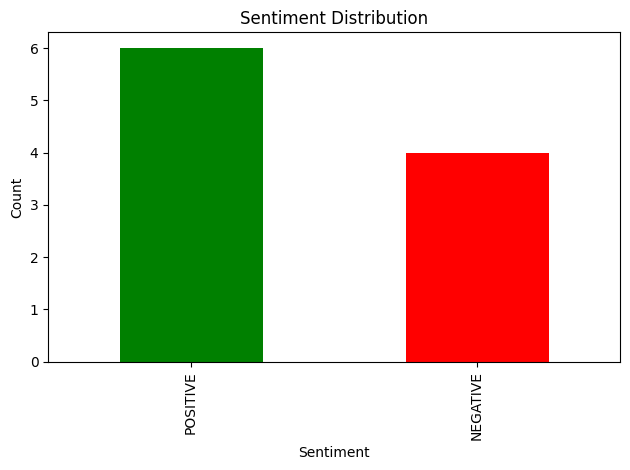

In [14]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt

def classify_sentences(sentences):
    results = classifier(sentences)
    labels = [r['label'] for r in results]
    scores = [round(r['score'], 2) for r in results]

    df = pd.DataFrame({
        "Sentence": sentences,
        "Sentiment": labels,
        "Confidence": scores
    })

    return df


df_results = classify_sentences(sentences)
print(df_results)

df_results['Sentiment'].value_counts().plot(kind='bar', title="Sentiment Distribution", ylabel="Count", xlabel="Sentiment", color=['green', 'red'])
plt.tight_layout()
plt.show()